上一篇 Embeddings 已经把文字变成了向量。这篇只补一个关键问题：**向量放哪？**

向量存储可以先按两类理解：

| 类型 | 代表 | 特点 |
| --- | --- | --- |
| 写入内存 | `InMemoryVectorStore` | 简单，适合实验；程序结束后数据丢失 |
| 写入本地数据库 | `Chroma` | 可以持久化到本地目录；重启后还能继续查 |

两类向量存储都围绕同一组核心动作：

```text
写入 -> 查询 -> 添加 -> 删除
```

这篇用同一份公司报销制度演示两遍：先跑内存版，再换成本地持久化版。


## 准备资料：本地 CSV -> Document

不管写入内存还是写入本地数据库，第一步都一样：先把本地资料加载成 LangChain 的 `Document`。


In [ ]:
from pathlib import Path

# 示例数据统一放在 rag/data 目录，方便后面反复运行和查看。
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

csv_path = data_dir / "finance_policy.csv"

# 模拟一份本地制度 CSV。
# content 是真正要被检索的正文；policy_id/category 用来追踪来源和分类。
csv_path.write_text(
    "policy_id,category,content\n"
    "FIN-001,差旅报销,出差住宿费需要在返回后 7 天内提交发票。\n"
    "FIN-002,招待费,客户招待费超过 500 元需要部门负责人审批。\n"
    "FIN-003,交通报销,打车报销需要提供行程单和付款截图。\n"
    "FIN-004,发票,电子发票可以在财务系统上传，不需要打印。\n",
    encoding="utf-8",
)

print(csv_path)


In [ ]:
from langchain_community.document_loaders.csv_loader import CSVLoader

loader = CSVLoader(
    file_path=str(csv_path),
    encoding="utf-8",
    # source_column 会写入 metadata["source"]，方便知道结果来自哪条制度。
    source_column="policy_id",
    # metadata_columns 会保留业务字段，后面展示来源、过滤分类都能用上。
    metadata_columns=("policy_id", "category"),
    # 只把正文列放进 page_content，避免 ID、分类等字段干扰语义检索。
    content_columns=("content",),
)

# 一行 CSV 会变成一个 Document。
docs = loader.load()

print(len(docs))
print(docs[0].page_content)
print(docs[0].metadata)


# 一、写入内存：`InMemoryVectorStore`

内存向量库适合学习和快速验证。它不用配置数据库，代码最短，但进程结束后数据也会消失。

## 1. 写入内存


In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_ollama import OllamaEmbeddings

# Embedding 模型负责把文本转成向量。
# 同一个向量库里建议固定使用同一个 embedding 模型。
embeddings = OllamaEmbeddings(
    model="qwen3-embedding:latest",
    base_url="http://localhost:11434",
)

# from_documents 会对 docs 批量向量化，然后写入内存向量库。
# InMemoryVectorStore 适合实验；进程结束后数据会丢失。
memory_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embeddings,
)


## 2. 查询内存向量库

用户问题也会被转成向量，再和库里的文档向量做相似度匹配。


In [ ]:
# k=2 表示返回最相近的 2 条 Document。
results = memory_store.similarity_search(
    "客户吃饭花了 800，需要谁审批？",
    k=2,
)

for doc in results:
    print(doc.page_content)
    print(doc.metadata)


`k` 不是越大越好。返回太少可能漏资料，返回太多也可能把模型吵晕，像开会时所有人同时发言。

## 3. 给内存库添加文档

制度会更新，增量资料也可以先落成文件，再用 loader 解析成 `Document`。


In [ ]:
new_csv_path = data_dir / "finance_policy_increment.csv"

# 模拟一份增量制度文件。真实项目里可能来自每日同步任务。
new_csv_path.write_text(
    "policy_id,category,content\n"
    "FIN-005,审批规则,报销单金额超过 3000 元，需要财务经理复核。\n",
    encoding="utf-8",
)

new_loader = CSVLoader(
    file_path=str(new_csv_path),
    encoding="utf-8",
    source_column="policy_id",
    metadata_columns=("policy_id", "category"),
    content_columns=("content",),
)

new_docs = new_loader.load()

# 用业务编号作为向量库 ID，后面删除、更新时能精确定位。
new_ids = [doc.metadata["policy_id"] for doc in new_docs]

memory_store.add_documents(
    documents=new_docs,
    ids=new_ids,
)

results = memory_store.similarity_search("报销 5000 块谁来复核？", k=1)
for doc in results:
    print(doc.page_content)
    print(doc.metadata)


## 4. 从内存库删除文档

RAG 不只是“加知识”，也要能清理过期知识。旧制度不删，模型就可能引用旧规定。

注意：删除后再查，`similarity_search(k=1)` 仍然会返回一条“最接近”的结果。这不代表它答对了，只代表向量库在剩余文档里挑了一个最近的。


In [ ]:
# 按 ID 删除，避免误删其他相似内容。
memory_store.delete(ids=["FIN-005"])

# with_score 可以看到检索分数，提醒我们：返回了不等于一定相关。
results = memory_store.similarity_search_with_score(
    "报销 5000 块谁来复核？",
    k=1,
)

for doc, score in results:
    print(doc.page_content)
    print(doc.metadata)
    print("score:", score)


# 二、写入本地数据库：`Chroma`

`Chroma` 更接近真实项目：它会把向量数据保存到本地目录。服务重启后，不需要重新加载所有文档再建索引。

安装依赖：

```bash
uv add langchain-chroma chromadb
```

## 1. 写入 Chroma


In [ ]:
from langchain_chroma import Chroma

# Chroma 会把数据持久化到这个目录，重启后还能重新打开。
persist_dir = Path("data/chroma_finance_policy")

# collection_name 类似一组向量数据的名字。
# ids 继续使用制度编号，方便后续删除或覆盖更新。
chroma_store = Chroma.from_documents(
    documents=docs,
    embedding=embeddings,
    ids=[doc.metadata["policy_id"] for doc in docs],
    collection_name="finance_policy",
    persist_directory=str(persist_dir),
)


向量写入Chroma后，可以读取本地chroma.sqlite3文件看一下长什么样

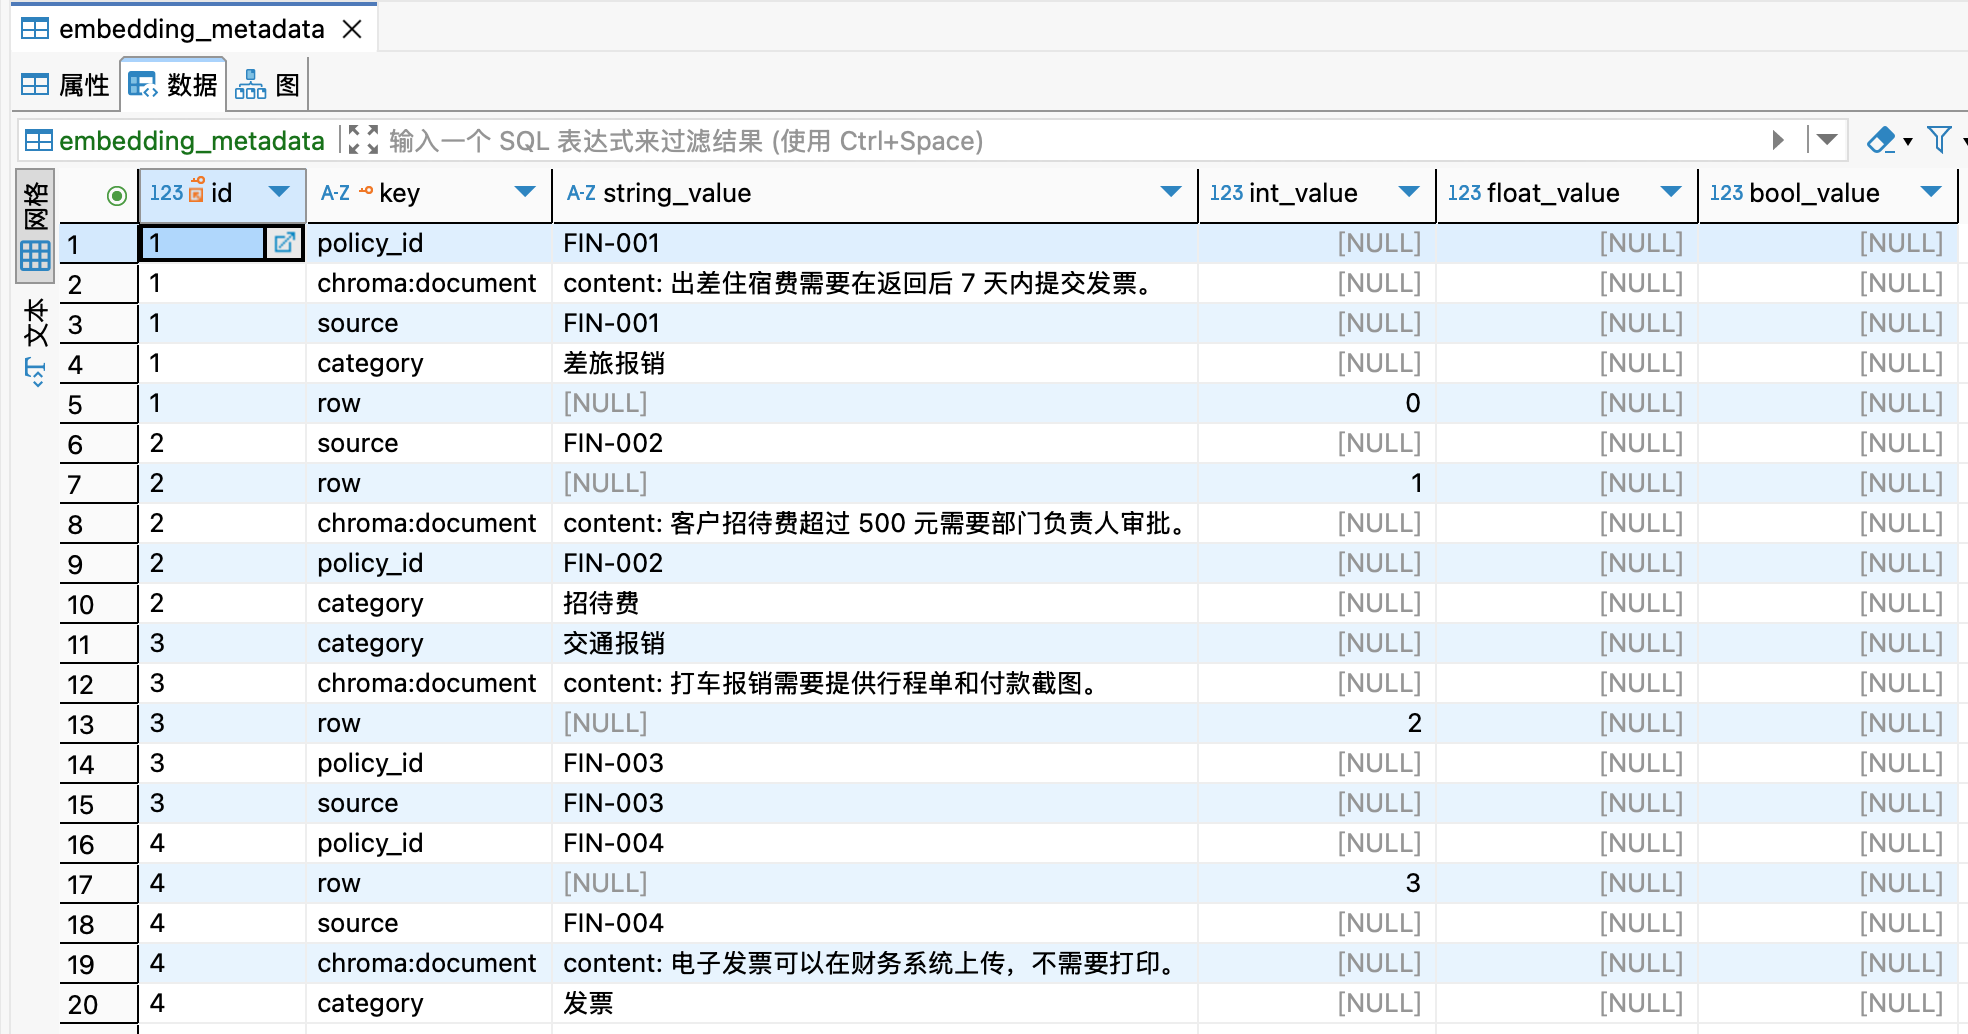

## 2. 查询 Chroma

换成 Chroma 后，查询方式仍然是 `similarity_search()`。这就是 LangChain 统一接口的价值。


In [ ]:
results = chroma_store.similarity_search(
    "电子发票要不要打印？",
    k=2,
)

for doc in results:
    print(doc.page_content)
    print(doc.metadata)


## 3. 给 Chroma 添加文档

同样使用 `add_documents()`。区别是这次数据会写入本地持久化库。


In [ ]:
chroma_store.add_documents(
    documents=new_docs,
    ids=new_ids,
)

results = chroma_store.similarity_search("报销 5000 块谁来复核？", k=1)
for doc in results:
    print(doc.page_content)
    print(doc.metadata)


## 4. 从 Chroma 删除文档

删除动作也是按 ID 来。用稳定业务 ID 的好处，在这里就很明显了。


In [ ]:
chroma_store.delete(ids=["FIN-005"])

results = chroma_store.similarity_search_with_score(
    "报销 5000 块谁来复核？",
    k=1,
)

for doc, score in results:
    print(doc.page_content)
    print(doc.metadata)
    print("score:", score)


## 5. 重新打开已有 Chroma 库

真实项目里，索引和查询经常分开：凌晨任务负责写入向量库，白天服务负责响应用户查询。


In [ ]:
# 这里不再 from_documents，因为不是重新建索引。
# 而是连接已经存在的 collection，直接用于查询。
chroma_store = Chroma(
    collection_name="finance_policy",
    embedding_function=embeddings,
    persist_directory="data/chroma_finance_policy",
)

results = chroma_store.similarity_search(
    "打车报销需要哪些材料？",
    k=2,
)

for doc in results:
    print(doc.page_content)
    print(doc.metadata)


## 小结

这篇其实只讲一件事：向量库不是只有“查”，而是要完整支持管理。

```text
InMemoryVectorStore：写入内存 -> 查询 -> 添加 -> 删除
Chroma：写入本地数据库 -> 查询 -> 添加 -> 删除 -> 重新打开
```

学习和快速验证，用 `InMemoryVectorStore`。想做一个重启后还记得资料的本地 RAG 原型，用 `Chroma`。

最后记住几个工程点：

1. 同一个向量库里尽量固定一个 Embedding 模型。
2. 文档 ID 用稳定的业务编号，比如制度编号、文章编号、工单编号。
3. metadata 别偷懒，来源、分类、更新时间、页码都可能成为回答依据。
4. 过期资料要删，不然 RAG 会把旧知识讲得很自信。
5. `k` 要调，返回了不代表一定相关，必要时要结合 score、阈值或 rerank。

大模型负责组织语言，向量库负责把资料找对。两个都靠谱，回答才靠谱。
